In [6]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

from shapely.geometry import Point
from sklearn.neighbors import KernelDensity
from pointpats import PointPattern

In [7]:
df = pd.read_csv("postal_code_floods.csv")

# Flood events to GeoDataFrame (EPSG:4326 → EPSG:3414)
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
).to_crs("EPSG:3414")

# Load planning area polygons
planning_area = gpd.read_file("../roadnetwork/geojson/planning_area.geojson").to_crs("EPSG:3414")

# Define unified study region (owin equivalent)
study_area = planning_area.unary_union

print(f"Loaded {len(gdf)} flood events across {len(planning_area)} planning areas")


Loaded 214 flood events across 55 planning areas


/var/folders/cw/6ny7fl_n26v475rpwb5gr_2m0000gn/T/ipykernel_5824/1810225306.py:14: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_area = planning_area.unary_union


In [8]:
coords = np.array(list(zip(gdf.geometry.x, gdf.geometry.y)))
pp = PointPattern(coords)

# Nearest neighbour distances
nn_dists, nn_idx = pp.knn(k=1)
avg_nn = nn_dists.mean()

# Expected NN distance under CSR
area = study_area.area
lambda_density = len(coords) / area
expected_nn = 1 / (2 * np.sqrt(lambda_density))

R = avg_nn / expected_nn

print(f"Observed NN distance: {avg_nn:.2f} m")
print(f"Expected NN distance (CSR): {expected_nn:.2f} m")
print(f"Clark–Evans R: {R:.3f}")

Observed NN distance: 107.92 m
Expected NN distance (CSR): 957.58 m
Clark–Evans R: 0.113


In [9]:
coords = np.vstack([gdf.geometry.x, gdf.geometry.y]).T

# Evaluation grid
xmin, ymin, xmax, ymax = planning_area.total_bounds
xx, yy = np.meshgrid(
    np.linspace(xmin, xmax, 300),
    np.linspace(ymin, ymax, 300)
)
grid_coords = np.vstack([xx.ravel(), yy.ravel()]).T

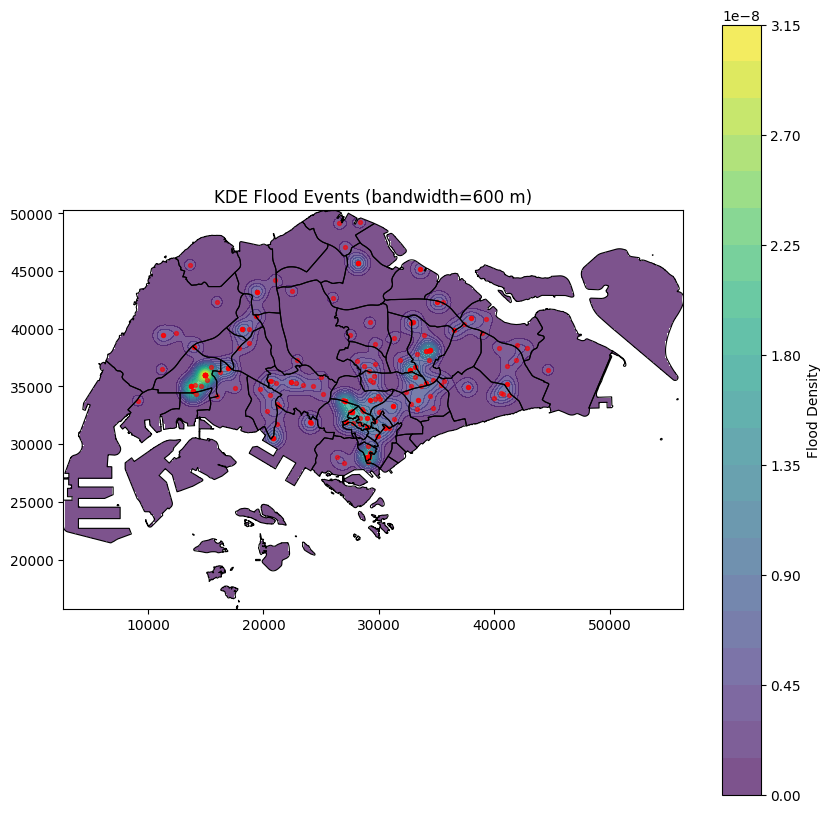

In [12]:
bandwidth = 600
kde = KernelDensity(bandwidth=bandwidth, kernel="gaussian").fit(coords)

zz = np.exp(kde.score_samples(grid_coords)).reshape(xx.shape)

# Mask outside planning area
mask = np.array([study_area.contains(Point(x, y)) for x, y in grid_coords]).reshape(xx.shape)
zz_masked = np.where(mask, zz, np.nan)

fig, ax = plt.subplots(figsize=(10,10))
planning_area.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8)
c = ax.contourf(xx, yy, zz_masked, cmap="viridis", levels=20, alpha=0.7)
gdf.plot(ax=ax, color="red", markersize=8, alpha=0.6)
fig.colorbar(c, ax=ax, label="Flood Density")
plt.title(f"KDE Flood Events (bandwidth={bandwidth} m)")
plt.show()

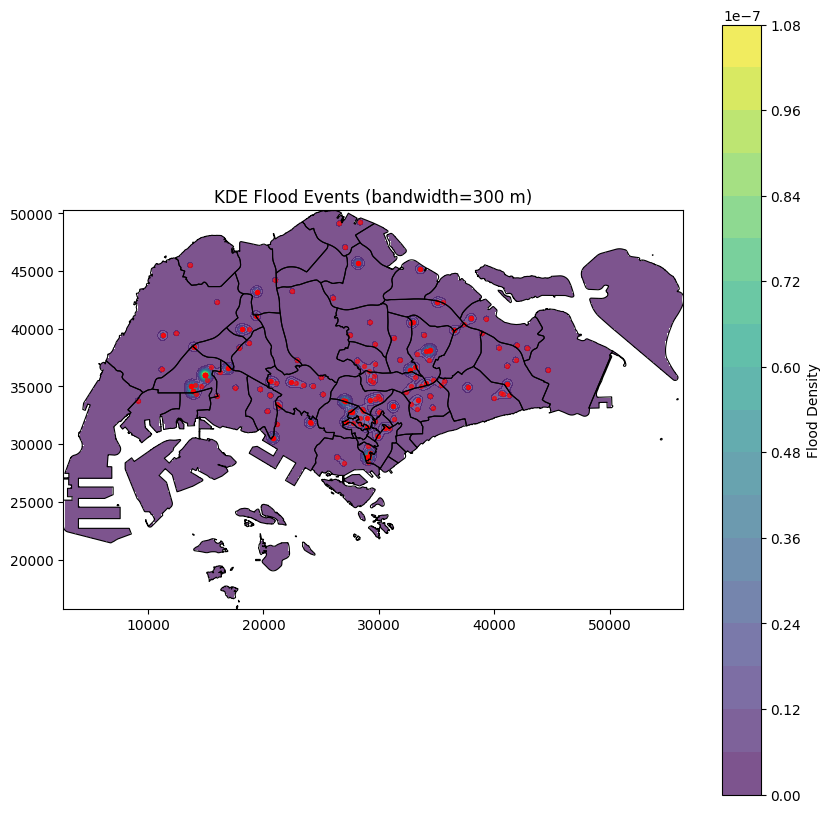

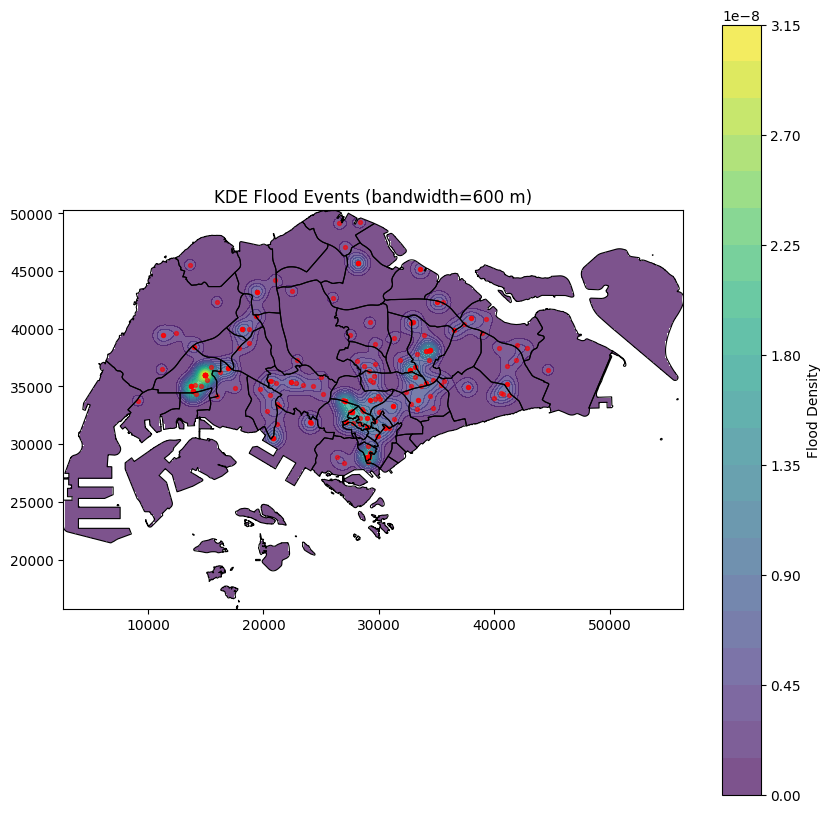

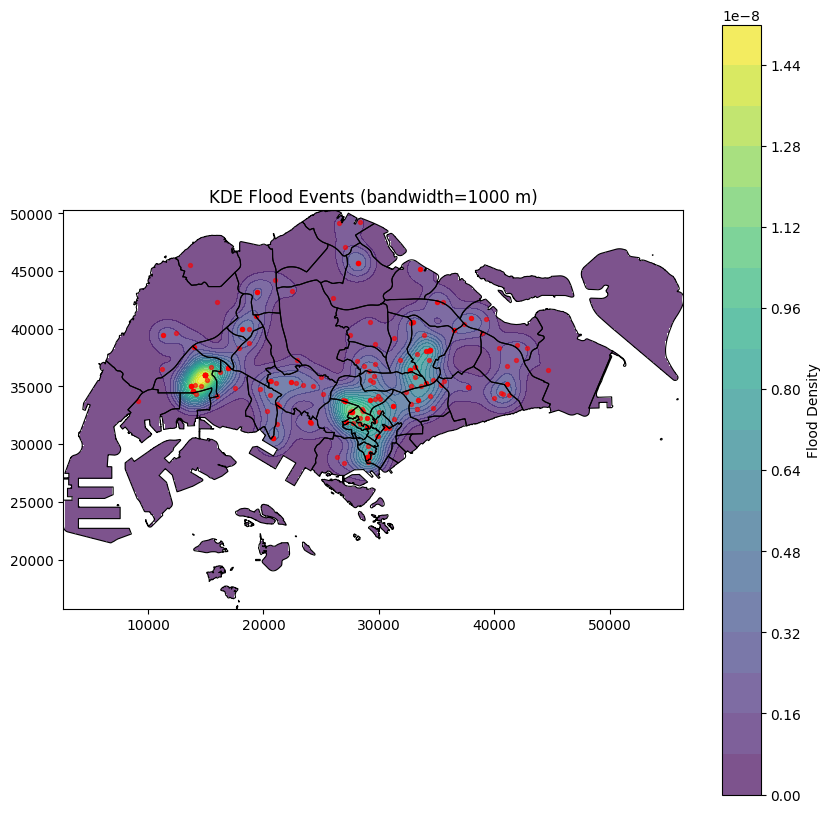

In [13]:
# ===============================================================
# 5. Bandwidth Comparison
# ===============================================================
for bw in [300, 600, 1000]:
    kde = KernelDensity(bandwidth=bw, kernel="gaussian").fit(coords)
    zz = np.exp(kde.score_samples(grid_coords)).reshape(xx.shape)
    mask = np.array([study_area.contains(Point(x, y)) for x, y in grid_coords]).reshape(xx.shape)
    zz_masked = np.where(mask, zz, np.nan)

    fig, ax = plt.subplots(figsize=(10,10))
    planning_area.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8)
    c = ax.contourf(xx, yy, zz_masked, cmap="viridis", levels=20, alpha=0.7)
    gdf.plot(ax=ax, color="red", markersize=8, alpha=0.6)
    fig.colorbar(c, ax=ax, label="Flood Density")
    plt.title(f"KDE Flood Events (bandwidth={bw} m)")
    plt.show()


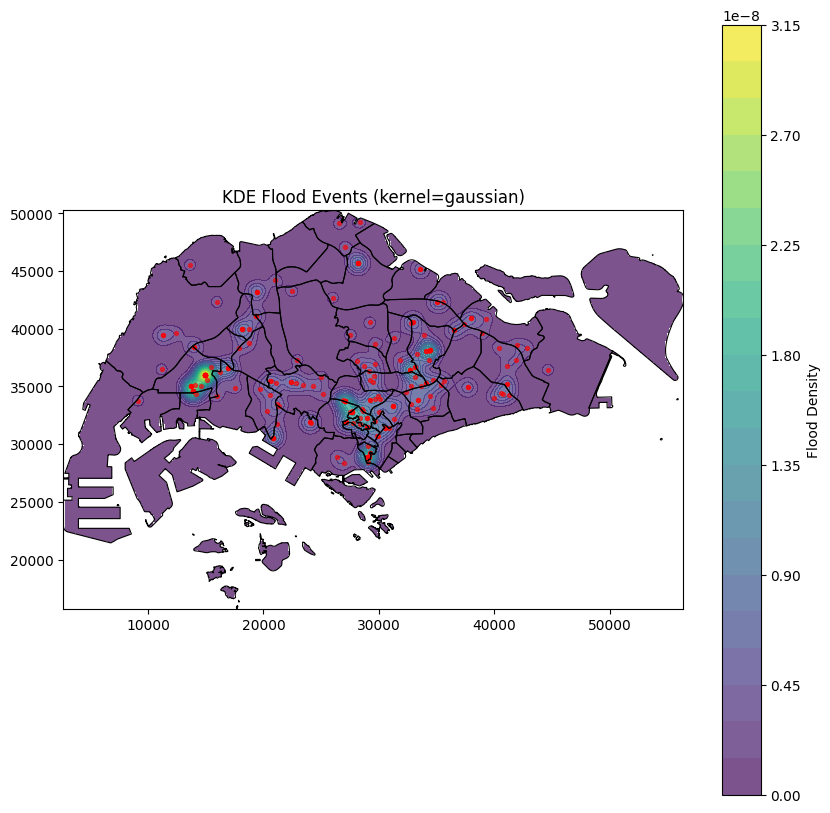

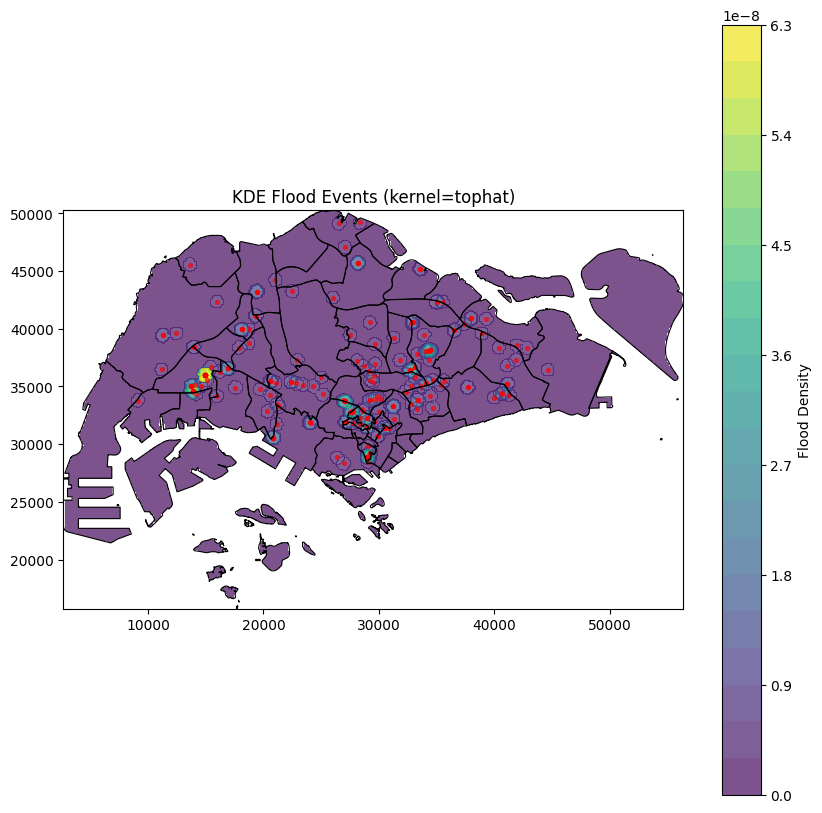

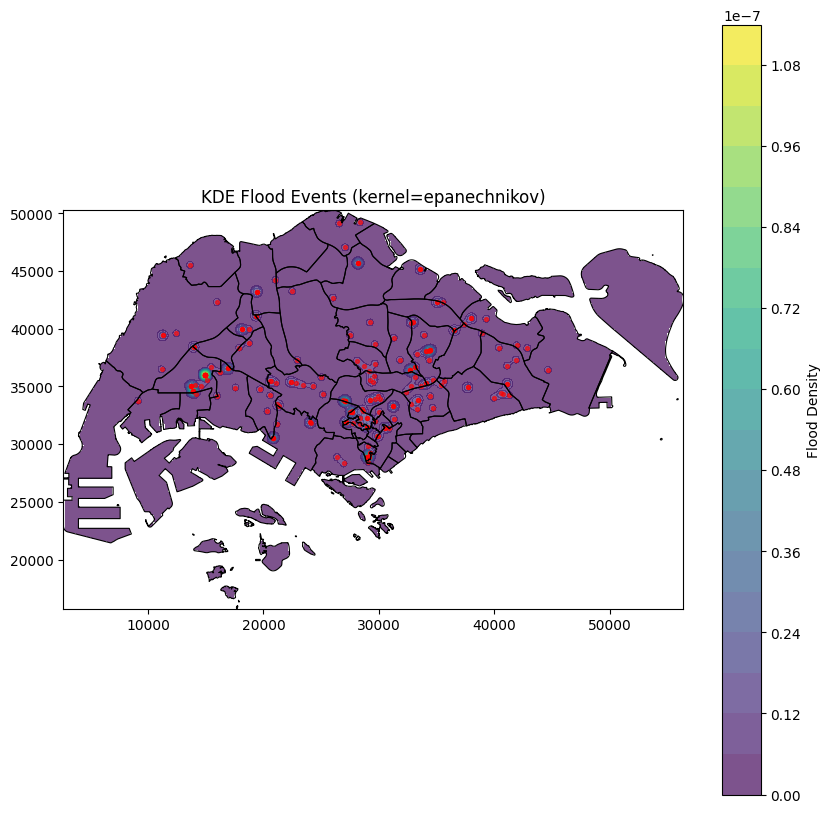

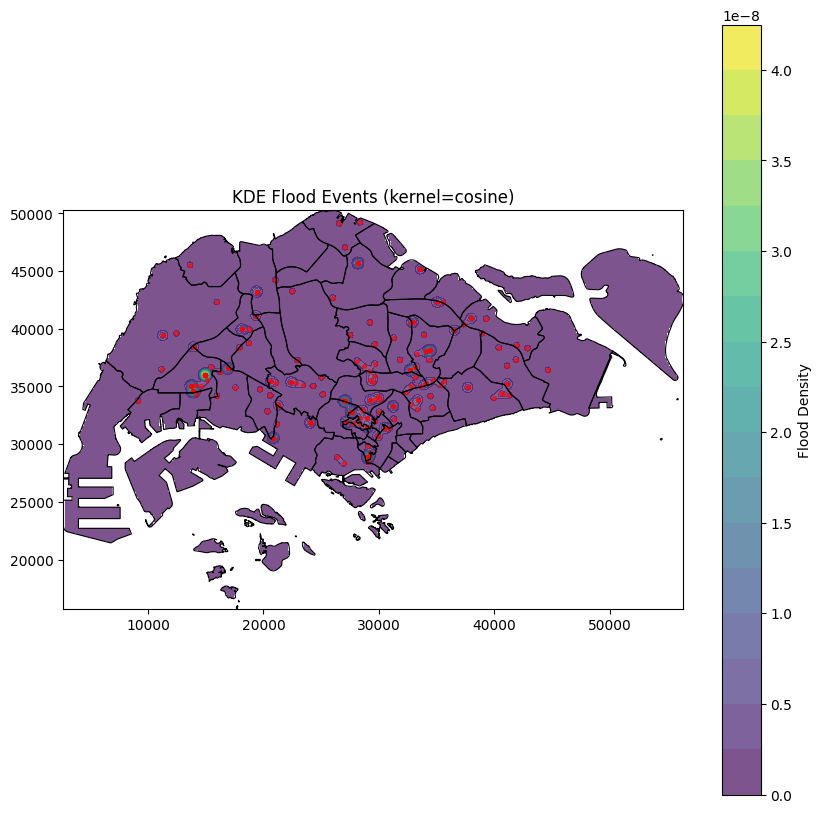

In [14]:
# ===============================================================
# 6. Kernel Comparison
# ===============================================================
for kernel in ["gaussian", "tophat", "epanechnikov", "cosine"]:
    kde = KernelDensity(bandwidth=600, kernel=kernel).fit(coords)
    zz = np.exp(kde.score_samples(grid_coords)).reshape(xx.shape)
    mask = np.array([study_area.contains(Point(x, y)) for x, y in grid_coords]).reshape(xx.shape)
    zz_masked = np.where(mask, zz, np.nan)

    fig, ax = plt.subplots(figsize=(10,10))
    planning_area.boundary.plot(ax=ax, edgecolor="black", linewidth=0.8)
    c = ax.contourf(xx, yy, zz_masked, cmap="viridis", levels=20, alpha=0.7)
    gdf.plot(ax=ax, color="red", markersize=8, alpha=0.6)
    fig.colorbar(c, ax=ax, label="Flood Density")
    plt.title(f"KDE Flood Events (kernel={kernel})")
    plt.show()